In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_s_curve

from Autoencoders import IsometricAutoencoder
from helper import load_optimizer_and_scheduler, save_optimizer_and_scheduler
from data import make_half_sphere

random_state = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [9]:
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
    
    def forward(self, x):
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
    
    def forward(self, z):
        return self.fc(z)

In [3]:
data, labels = make_half_sphere(n_samples=2000, noise=0.05, random_state=random_state)
data = torch.tensor(data, dtype=torch.float32).to(device)
val_data, val_labels = make_half_sphere(n_samples=1000, noise=0.05, random_state=random_state+1)
val_data = torch.tensor(val_data, dtype=torch.float32).to(device)

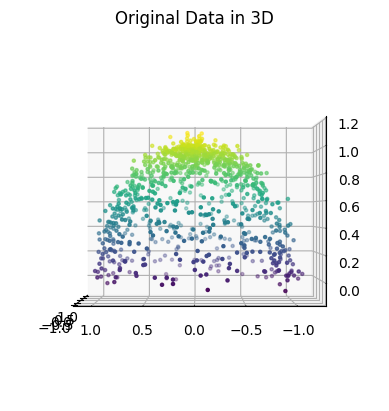

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0].cpu(), data[:, 1].cpu(), data[:, 2].cpu(), c=labels, s=5)
ax.set_title("Original Data in 3D")
ax.view_init(0, 180, 0)
plt.show()

In [5]:
# define model parameters
latent_dim = 2
input_dim = data.shape[1]
output_dim = data.shape[1]
batch_size = 64

train_dataloader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False)

In [6]:
lambda_isos = np.logspace(-3, 2, 10)

In [ ]:
num_epochs = 100
# train same model multiple times to average results
num_models = 4

recon_errors = []
regularization_errors = []


for i, lambda_iso in enumerate(lambda_isos):
    recon_error = 0
    regularization = 0
    for j in range(num_models):
        print(f"Training model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f}")
        
        encoder = Encoder(input_dim, latent_dim).to(device)
        decoder = Decoder(latent_dim, output_dim).to(device)
        model = IsometricAutoencoder(encoder, decoder, lambda_iso=lambda_iso).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

        # Train the model
        model.train_model(train_dataloader, val_dataloader, batch_size=batch_size, epochs=num_epochs,
                          optimizer=optimizer, scheduler=scheduler, verbose=True)

        # Save the model and optimizer state
        model_path = f"models/isometric_autoencoder_half_sphere_lambda_{lambda_iso:.3f}_model_{j+1}.pth"
        torch.save(model.state_dict(), model_path)
        print(f"Model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f} trained and saved.")

        # evaluation
        model.eval()
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)
        
        recon_error += nn.MSELoss()(reconstruction, val_data).item()

        regularization += model.isometry_loss(model.decoder, encoded_data, create_graph=False, augment=False).item()
    
    recon_errors.append(recon_error/ num_models)
    regularization_errors.append(regularization/num_models)
    

Training model 1/4 with lambda_iso=0.001
Epoch [100/100], Loss: 0.00098741, Reconstruction Loss: 0.00096850, Isometric Loss: 0.01891426
Epoch [100/100], Validation Loss: 0.00110327, Reconstruction Loss: 0.00108425, Isometric Loss: 0.01901699
Model 1/4 with lambda_iso=0.001 trained and saved.
Training model 2/4 with lambda_iso=0.001
Epoch [100/100], Loss: 0.00099085, Reconstruction Loss: 0.00097135, Isometric Loss: 0.01950107
Epoch [100/100], Validation Loss: 0.00123068, Reconstruction Loss: 0.00120871, Isometric Loss: 0.02197020
Model 2/4 with lambda_iso=0.001 trained and saved.
Training model 3/4 with lambda_iso=0.001
Epoch [100/100], Loss: 0.00099143, Reconstruction Loss: 0.00096702, Isometric Loss: 0.02441710
Epoch [100/100], Validation Loss: 0.00121282, Reconstruction Loss: 0.00118592, Isometric Loss: 0.02690393
Model 3/4 with lambda_iso=0.001 trained and saved.
Training model 4/4 with lambda_iso=0.001
Epoch [100/100], Loss: 0.00096284, Reconstruction Loss: 0.00094924, Isometric Lo

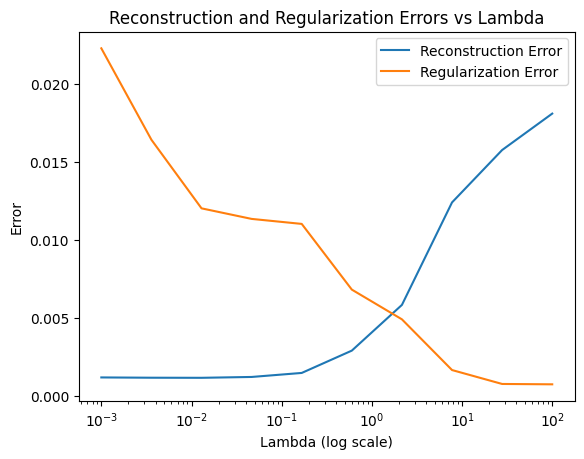

In [11]:
plt.plot(lambda_isos, recon_errors, label='Reconstruction Error')
plt.plot(lambda_isos, regularization_errors, label='Regularization Error')
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Error')
plt.title('Reconstruction and Regularization Errors vs Lambda')
plt.legend()
plt.show()

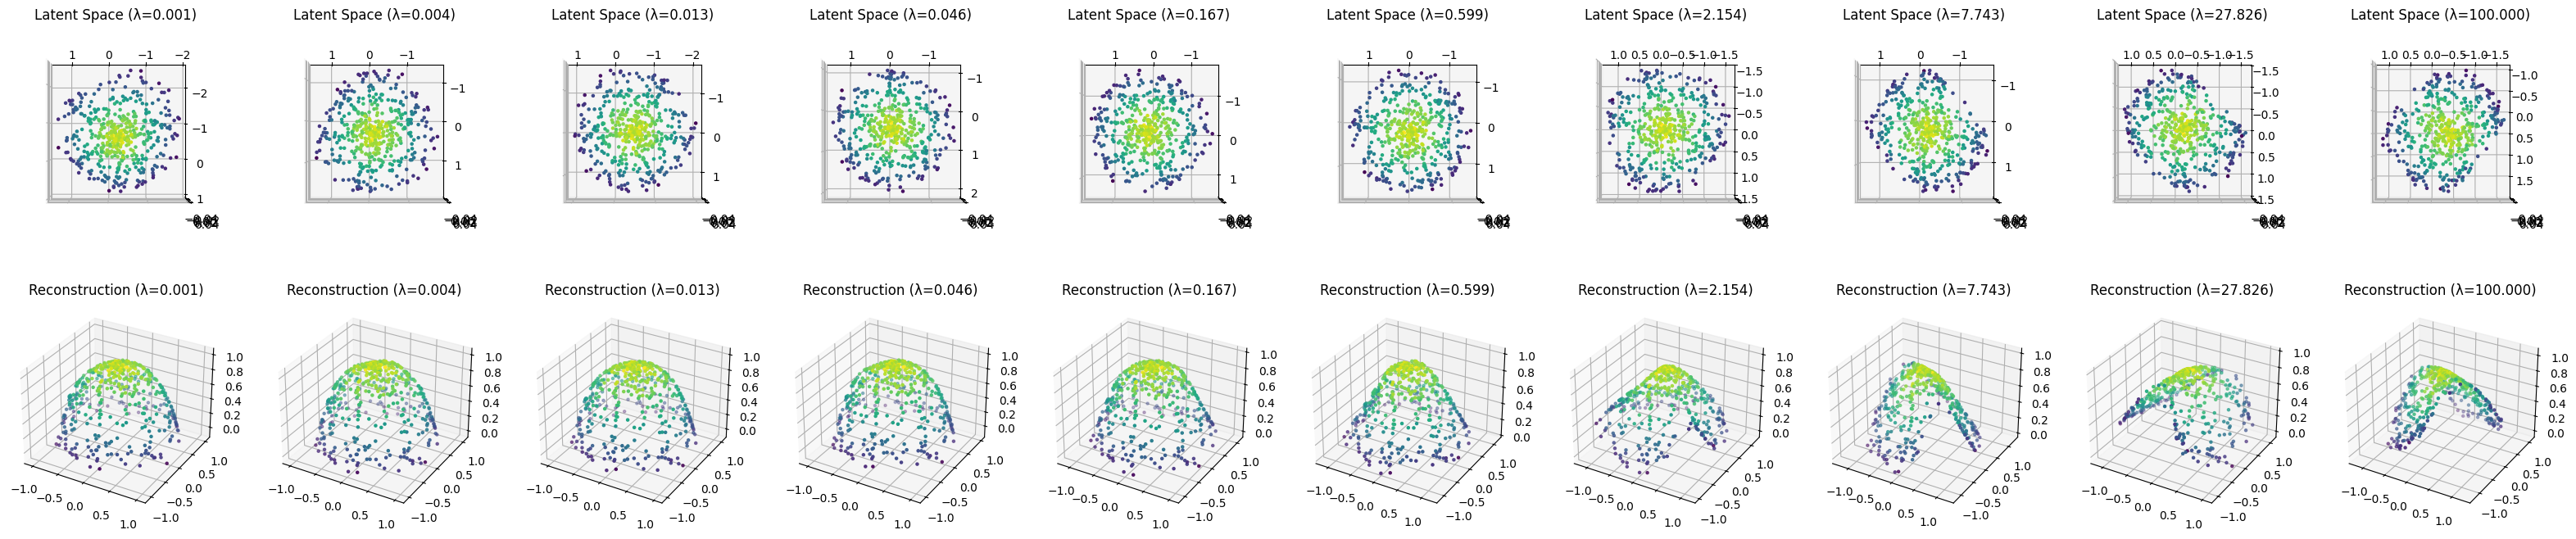

In [39]:
# plot samples and latent space at different lambdas
fig, axs = plt.subplots(2, 10, figsize=(40, 8), subplot_kw=dict(projection='3d'))
for i, lambda_iso in enumerate(lambda_isos):
    model_path = f"models/isometric_autoencoder_half_sphere/isometric_autoencoder_half_sphere_lambda_{lambda_iso:.3f}_model_1.pth"
    model = IsometricAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_iso=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    axs[0, i].scatter(encoded_data[:, 0].cpu(), encoded_data[:, 1].cpu(), c=val_labels, s=5)
    axs[0, i].set_title(f'Latent Space (λ={lambda_iso:.3f})')
    axs[0, i].view_init(90, 90, 0)
    # axs[0, i].set_xticks([])
    # axs[0, i].set_yticks([])
    #plot 3d data
    axs[1, i].scatter(reconstruction[:, 0].cpu(), reconstruction[:, 1].cpu(), reconstruction[:, 2].cpu(), c=val_labels, s=5)
    axs[1, i].set_title(f'Reconstruction (λ={lambda_iso:.3f})')


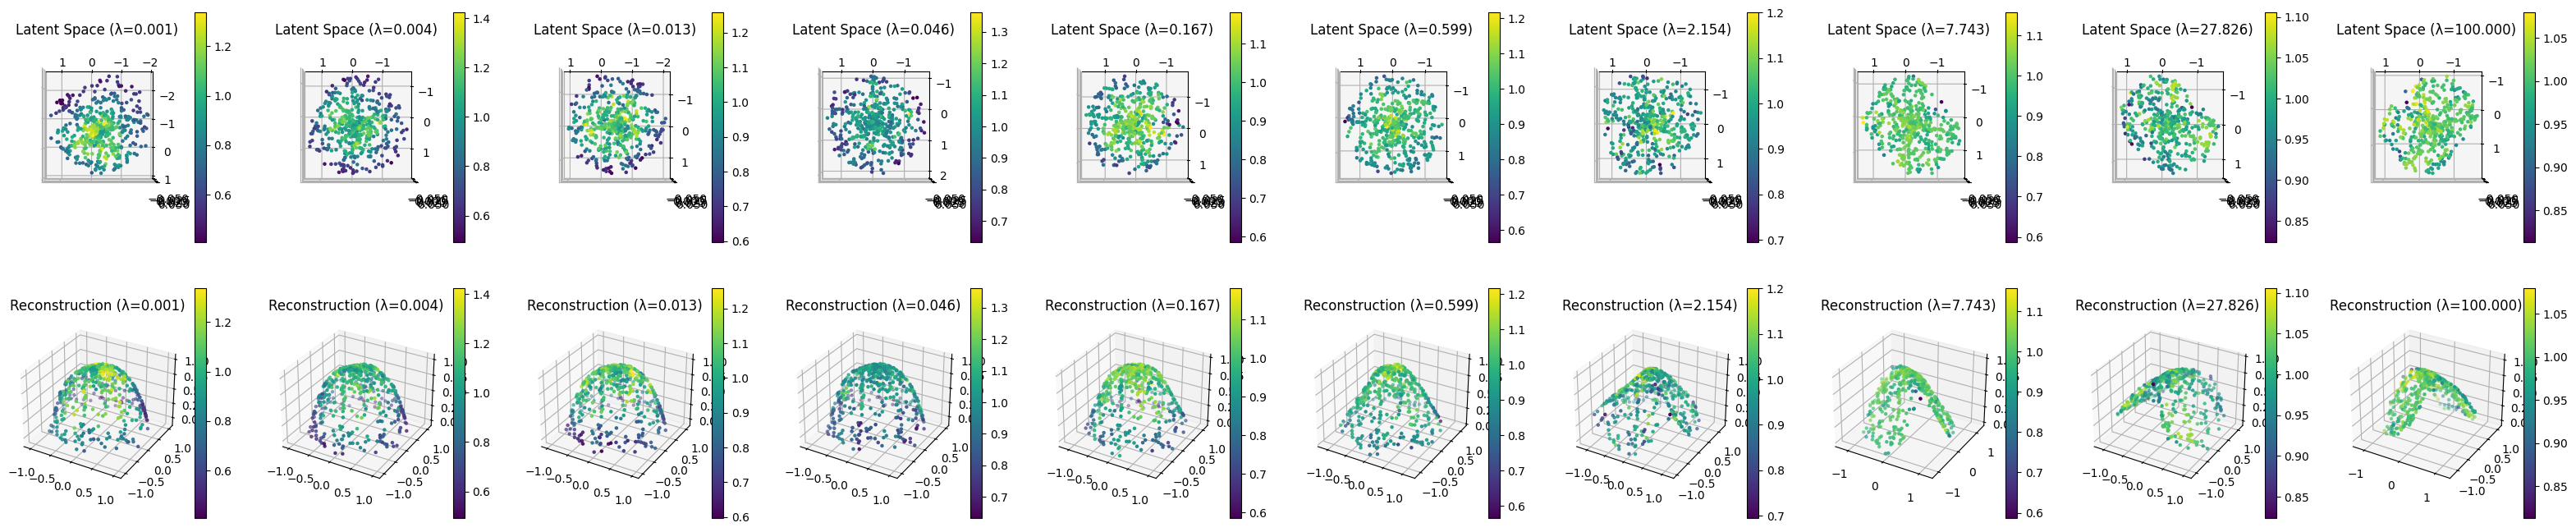

In [42]:
fig, axs = plt.subplots(2, 10, figsize=(40, 8), subplot_kw=dict(projection='3d'))
for i, lambda_iso in enumerate(lambda_isos):
    model_path = f"models/isometric_autoencoder_half_sphere/isometric_autoencoder_half_sphere_lambda_{lambda_iso:.3f}_model_1.pth"
    model = IsometricAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_iso=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    trace_vals = np.zeros_like(encoded_data[:, 0].cpu())
    for j, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension
        y = model.decode(z)  # Decode to get reconstruction
        y = y.squeeze(0)  # Remove batch dimension

        # Compute the Jacobian J of the decoder at point z
        J = torch.autograd.functional.jacobian(model.decode, z)[0,:,0,:]

        # Compute the trace of J^T J
        JtJ = J.T @ J
        trace_JtJ = torch.trace(JtJ)

        # Store the trace value as a label for the point
        trace_vals[j] = trace_JtJ.item() / JtJ.shape[0]  # Normalize by the number of dimensions

    p = axs[0, i].scatter(encoded_data[:, 0].cpu(), encoded_data[:, 1].cpu(), c=trace_vals, s=5)
    plt.colorbar(p)
    axs[0, i].set_title(f'Latent Space (λ={lambda_iso:.3f})')
    axs[0, i].view_init(90, 90, 0)
    # axs[0, i].set_xticks([])
    # axs[0, i].set_yticks([])
    #plot 3d data
    p = axs[1, i].scatter(reconstruction[:, 0].cpu(), reconstruction[:, 1].cpu(), reconstruction[:, 2].cpu(), c=trace_vals, s=5)
    plt.colorbar(p)
    axs[1, i].set_title(f'Reconstruction (λ={lambda_iso:.3f})')

In [15]:
import pandas as pd

from torch.func import functional_call, jacrev, vmap

def gini(w: torch.Tensor) -> torch.Tensor:
    r"""The Gini coefficient from the `"Improving Molecular Graph Neural
    Network Explainability with Orthonormalization and Induced Sparsity"
    <https://arxiv.org/abs/2105.04854>`_ paper.

    Computes a regularization penalty :math:`\in [0, 1]` for each row of a
    matrix according to

    .. math::
        \mathcal{L}_\textrm{Gini}^i = \sum_j^n \sum_{j'}^n \frac{|w_{ij}
         - w_{ij'}|}{2 (n^2 - n)\bar{w_i}}

    and returns an average over all rows.

    Args:
        w (torch.Tensor): A two-dimensional tensor.
    """
    s = 0
    for row in w:
        t = row.repeat(row.size(0), 1)
        u = (t - t.T).abs().sum() / (2 * (row.size(-1)**2 - row.size(-1)) *
                                     row.abs().mean() + torch.finfo().eps)
        s += u
    s /= w.shape[0]
    return s

def get_batch_jacobian(func, inputs):
    params = dict(func.named_parameters())

    def fmodel(params, inputs):
        return functional_call(func, params, inputs)

    jacobians = vmap(jacrev(fmodel, argnums=(1)), in_dims=(None,0))(params, inputs)
    return jacobians

def evaluate_conformality(model, data):
    # still needs flattening for convolutions
    model.eval()
    with torch.no_grad():
        data_dim = data.shape[1]
        # latent samples
        latent = model.encode(data)
        latent_dim = latent.shape[1]

        # Compute the Jacobian of the decoder
        jacobians = get_batch_jacobian(model.decoder, latent)
        jTjs = torch.einsum('bji,bjk->bik', jacobians, jacobians)
        traces = vmap(torch.trace)(jTjs)
        lambda_factors = traces / latent.shape[1]

        # gini for diagonal elements
        diagonals = jTjs.diagonal(dim1=1, dim2=2)
        gini_value = gini(diagonals)

        # off diag mean, norm
        off_diagonal = jTjs - torch.diag_embed(diagonals)
        off_diag_mean = off_diagonal.abs().mean(dim=(1, 2))
        off_diag_norm = off_diagonal.norm(dim=(1, 2))
        off_diag_mean_normed = off_diag_mean / lambda_factors
        off_diag_norm_normed = off_diag_norm / lambda_factors

        # jTj - lambda*I mean, norm
        eye = torch.eye(jTjs.shape[1], device=jTjs.device).repeat(jTjs.shape[0], 1, 1)
        jTj_minus_lambdaI = jTjs - lambda_factors.unsqueeze(1).unsqueeze(2).repeat(1, jTjs.shape[1], jTjs.shape[1]) * eye
        jTj_minus_lambdaI_mean = jTj_minus_lambdaI.abs().mean(dim=(1, 2))
        jTj_minus_lambdaI_norm = jTj_minus_lambdaI.norm(dim=(1, 2))
        jTj_minus_lambdaI_mean_normed = jTj_minus_lambdaI_mean / lambda_factors
        jTj_minus_lambdaI_norm_normed = jTj_minus_lambdaI_norm / lambda_factors

        # determinant of jacobian vs sqrt lambda**m
        jacobian_determinants = torch.sqrt(torch.linalg.det(jTjs))
        determinant_vs_estimate = jacobian_determinants / (torch.sqrt(lambda_factors**latent_dim) + torch.finfo(torch.float32).eps)

        # std of latent space
        latent_std = latent.std(dim=0)
        
        return {
            'reconstruction_error': torch.nn.MSELoss()(data, model.decode(latent)).item(),
            'diagonal_gini': gini_value.item(),
            'lambda_mean': lambda_factors.mean().item(),
            'lambda_std': lambda_factors.std().item(),
            'lambda_std_normed': (lambda_factors.std() /lambda_factors.mean()).item(),
            'off_diag_mean': off_diag_mean.mean().item(),
            'off_diag_norm': off_diag_norm.mean().item(),
            'off_diag_mean_normed': off_diag_mean_normed.mean().item(),
            'off_diag_norm_normed': off_diag_norm_normed.mean().item(),
            'jTj_minus_lambdaI_mean': jTj_minus_lambdaI_mean.mean().item(),
            'jTj_minus_lambdaI_norm': jTj_minus_lambdaI_norm.mean().item(),
            'jTj_minus_lambdaI_mean_normed': jTj_minus_lambdaI_mean_normed.mean().item(),
            'jTj_minus_lambdaI_norm_normed': jTj_minus_lambdaI_norm_normed.mean().item(),
            'determinant_vs_estimate_mean': determinant_vs_estimate.mean().item(),
            'determinant_vs_estimate_std': determinant_vs_estimate.std().item(),
            'latent_std': latent_std.mean().item(),
            'latent_std_max': latent_std.max().item(),
            'latent_std_min': latent_std.min().item(),
            'latent_norm': latent.norm().item(),
        }

In [16]:
statses = []
for i, lambda_iso in enumerate(lambda_isos):
    model_path = f"models/isometric_autoencoder_half_sphere/isometric_autoencoder_half_sphere_lambda_{lambda_iso:.3f}_model_1.pth"
    model = IsometricAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_iso=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    statses.append(evaluate_conformality(model, data))

df = pd.DataFrame(statses, index=lambda_isos)
# styled_df = df.style.highlight_min(color='green').highlight_max(color='coral')

In [17]:
styled_df = df.style \
    .background_gradient(subset=[
            'reconstruction_error',
            'diagonal_gini',
            'lambda_std',
            'lambda_std_normed',
            'off_diag_mean',
            'off_diag_norm',
            'off_diag_mean_normed',
            'off_diag_norm_normed',
            'jTj_minus_lambdaI_mean',
            'jTj_minus_lambdaI_norm',
            'jTj_minus_lambdaI_mean_normed',
            'jTj_minus_lambdaI_norm_normed',
            'determinant_vs_estimate_std',
            ], cmap='Reds') \
    .background_gradient(subset=[
        'determinant_vs_estimate_mean'
    ], cmap='Greens')\
    .background_gradient(subset=[
        'lambda_mean',
        'latent_std',
        'latent_std_max',
        'latent_std_min',
        'latent_norm',
    ], cmap='Blues')

styled_df

,reconstruction_error,diagonal_gini,lambda_mean,lambda_std,lambda_std_normed,off_diag_mean,off_diag_norm,off_diag_mean_normed,off_diag_norm_normed,jTj_minus_lambdaI_mean,jTj_minus_lambdaI_norm,jTj_minus_lambdaI_mean_normed,jTj_minus_lambdaI_norm_normed,determinant_vs_estimate_mean,determinant_vs_estimate_std,latent_std,latent_std_max,latent_std_min,latent_norm
0.001000,0.000887,0.103804,0.944953,0.220134,0.232957,0.061945,0.175207,0.068558,0.193912,0.108612,0.241833,0.120460,0.267895,0.974948,0.030143,0.626555,0.629950,0.623160,35.827374
0.003594,0.000974,0.093896,0.961814,0.184354,0.191673,0.050913,0.144002,0.056534,0.159903,0.093025,0.205562,0.103482,0.228349,0.981577,0.021318,0.608866,0.617824,0.599907,29.188034
0.012915,0.000974,0.090351,0.974563,0.139164,0.142796,0.053311,0.150786,0.057724,0.163269,0.094882,0.209656,0.102900,0.226919,0.979966,0.027058,0.601103,0.603206,0.599001,30.676298
0.046416,0.001061,0.117966,0.964930,0.118428,0.122732,0.055181,0.156075,0.059315,0.167768,0.109743,0.242706,0.118298,0.261471,0.973301,0.031682,0.603521,0.616330,0.590711,30.379614
0.166810,0.001189,0.104182,0.973395,0.115457,0.118613,0.046212,0.130707,0.050742,0.143519,0.093254,0.206730,0.102833,0.227589,0.977738,0.031622,0.603048,0.603968,0.602127,27.135483
0.599484,0.002583,0.107137,0.984957,0.088273,0.089621,0.045919,0.129877,0.048043,0.135886,0.097231,0.216409,0.101611,0.226125,0.982357,0.018809,0.593637,0.594933,0.592341,27.276567
2.154435,0.004532,0.086423,0.990810,0.082626,0.083392,0.033489,0.094721,0.034328,0.097094,0.074803,0.167751,0.077539,0.174118,0.989611,0.013409,0.579944,0.589709,0.570178,26.066212
7.742637,0.007919,0.038617,0.996922,0.050535,0.050691,0.019491,0.055129,0.019947,0.056420,0.038610,0.085064,0.039256,0.086542,0.997407,0.003858,0.586925,0.600504,0.573345,27.772381
27.825594,0.011584,0.031691,1.004631,0.040673,0.040485,0.015884,0.044927,0.015989,0.045222,0.031648,0.070352,0.031834,0.070809,0.998271,0.002473,0.554975,0.556589,0.553360,25.081972
100.000000,0.013555,0.019040,1.003142,0.032233,0.032132,0.010669,0.030175,0.010708,0.030288,0.020124,0.044120,0.020229,0.044355,0.999250,0.001379,0.556329,0.576292,0.536366,30.383453


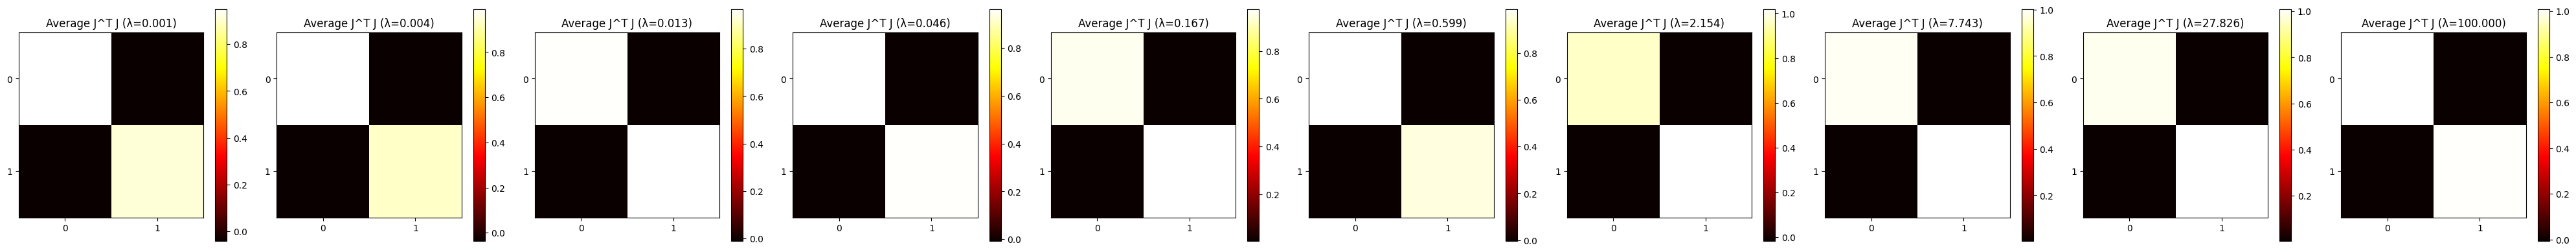

In [8]:
fig, axs = plt.subplots(1, 10, figsize=(40, 4))
for i, lambda_iso in enumerate(lambda_isos):
    model_path = f"models/isometric_autoencoder_half_sphere/isometric_autoencoder_half_sphere_lambda_{lambda_iso:.3f}_model_1.pth"
    model = IsometricAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_iso=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    JtJs = torch.zeros((latent_dim, latent_dim)).to(device)
    for j, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension
        y = model.decode(z)  # Decode to get reconstruction
        y = y.squeeze(0)  # Remove batch dimension

        # Compute the Jacobian J of the decoder at point z
        J = torch.autograd.functional.jacobian(model.decode, z)[0,:,0,:]

        # Compute the trace of J^T J
        JtJ = J.T @ J
        JtJs += JtJ
    JtJs /= len(encoded_data)  # Average over all points

    p = axs[i].imshow(JtJs.cpu().numpy(), cmap='hot')
    plt.colorbar(p)
    axs[i].set_title(f'Average J^T J (λ={lambda_iso:.3f})')
    axs[i].set_xticks(range(latent_dim))
    axs[i].set_yticks(range(latent_dim))
plt.tight_layout()
plt.show()

In [ ]:
def diagonality_loss(func, z):
    device = z.device
    losses = []
    for i, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension
        y = func(z)  # Decode to get reconstruction
        y = y.squeeze(0)  # Remove batch dimension

        # Compute the Jacobian J of the decoder at point z
        J = torch.autograd.functional.jacobian(func, z)[0,:,0,:]
        JtJ = J.transpose(0, 1) @ J

        eye = torch.eye(JtJ.size(0), device=device)
        off_diag_mask = 1.0 - eye
        off_diag_elements = JtJ[off_diag_mask.bool()]
        loss_matrix = off_diag_elements ** 2

        losses.append(loss_matrix.mean().item())
    
    return np.mean(losses).item()
        

In [32]:
# measure isometry, scaled isometry, conformity, diagonality, (angle preservation, kl)
from metrics import isometry_loss, scaled_isometry_loss, conformality_loss

for i, lambda_iso in enumerate(lambda_isos):
    print(f"Evaluating model with lambda_iso={lambda_iso:.3f}")
    model_path = f"models/isometric_autoencoder_half_sphere/isometric_autoencoder_half_sphere_lambda_{lambda_iso:.3f}_model_3.pth"
    model = IsometricAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_iso=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))

    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    isometry = isometry_loss(model.decoder, encoded_data, create_graph=False, augment=False)
    scaled_isometry = scaled_isometry_loss(model.decoder, encoded_data, create_graph=False, augment=False)
    conformality = conformality_loss(model.decoder, encoded_data)
    diagonality = diagonality_loss(model.decoder, encoded_data)
    print(f"Isometry Loss: {isometry.item()}")
    print(f"Scaled Isometry Loss: {scaled_isometry.item()}")
    print(f"Conformality Loss: {conformality.item()}")
    print(f"Diagonality Loss: {diagonality}")
    print("-" * 50)

Evaluating model with lambda_iso=0.001
Isometry Loss: 0.030198201537132263
Scaled Isometry Loss: 0.5588494539260864
Conformality Loss: 45.173675537109375
Diagonality Loss: 0.025357555102318588
--------------------------------------------------
Evaluating model with lambda_iso=0.004
Isometry Loss: 0.020447447896003723
Scaled Isometry Loss: 0.5480147004127502
Conformality Loss: 34.43684387207031
Diagonality Loss: 0.017241241908394104
--------------------------------------------------
Evaluating model with lambda_iso=0.013
Isometry Loss: 0.011444643139839172
Scaled Isometry Loss: 0.5289701819419861
Conformality Loss: 42.44587707519531
Diagonality Loss: 0.021127933980045942
--------------------------------------------------
Evaluating model with lambda_iso=0.046
Isometry Loss: 0.01173069141805172
Scaled Isometry Loss: 0.5163232684135437
Conformality Loss: 37.75851821899414
Diagonality Loss: 0.01960496960456461
--------------------------------------------------
Evaluating model with lambda_

In [ ]:
#########

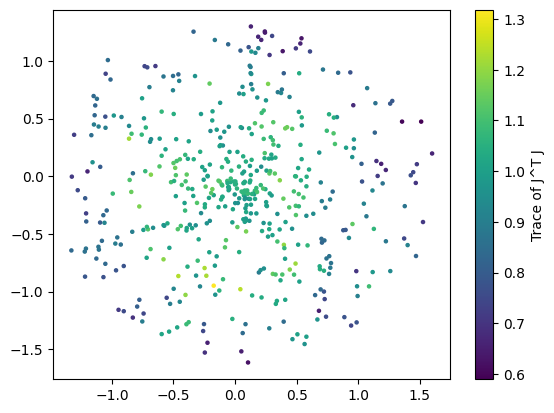

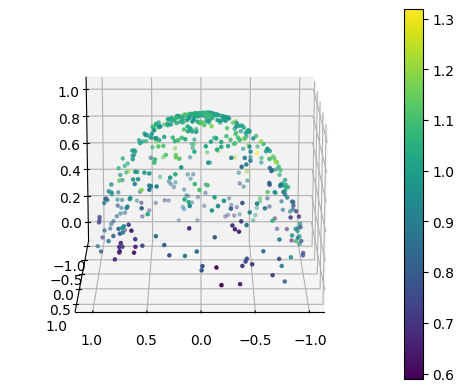

In [37]:
#map latent space to dataspace and label each point with trace of JtJ
lambda_iso = lambda_isos[3]
model_path = f"models/isometric_autoencoder_half_sphere/isometric_autoencoder_half_sphere_lambda_{lambda_iso:.3f}_model_2.pth"
model = IsometricAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_iso=lambda_iso).to(device)
model.load_state_dict(torch.load(model_path))

model.eval()
with torch.no_grad():
    encoded_data = model.encode(val_data)
    reconstruction = model.decode(encoded_data)

trace_vals = np.zeros_like(encoded_data[:, 0].cpu())
for i, z in enumerate(encoded_data):
    z = z.unsqueeze(0)  # Add batch dimension
    y = model.decode(z)  # Decode to get reconstruction
    y = y.squeeze(0)  # Remove batch dimension

    # Compute the Jacobian J of the decoder at point z
    J = torch.autograd.functional.jacobian(model.decode, z)[0,:,0,:]

    # Compute the trace of J^T J
    JtJ = J.T @ J
    trace_JtJ = torch.trace(JtJ)

    # Store the trace value as a label for the point
    trace_vals[i] = trace_JtJ.item() / JtJ.shape[0]  # Normalize by the number of dimensions

plt.scatter(encoded_data[:, 0].cpu(), encoded_data[:, 1].cpu(), c=trace_vals, s=5)
plt.colorbar(label='Trace of J^T J')

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(reconstruction[:, 0].cpu(), reconstruction[:, 1].cpu(), reconstruction[:, 2].cpu(), c=trace_vals, cmap='viridis', s=5)
ax.view_init(15, 90, 0)
plt.colorbar(p)
plt.show()